In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from darts import TimeSeries
from darts.dataprocessing.transformers import Scaler

##### on simule GARCH (returns and vol)

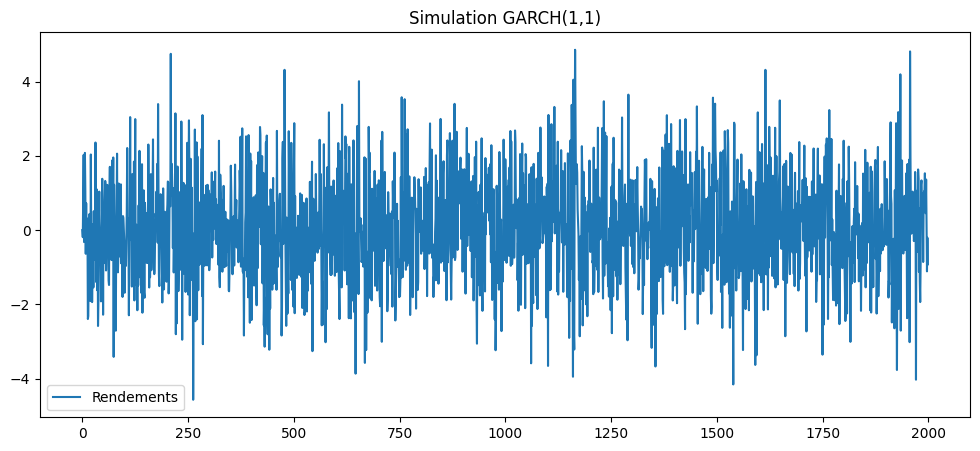

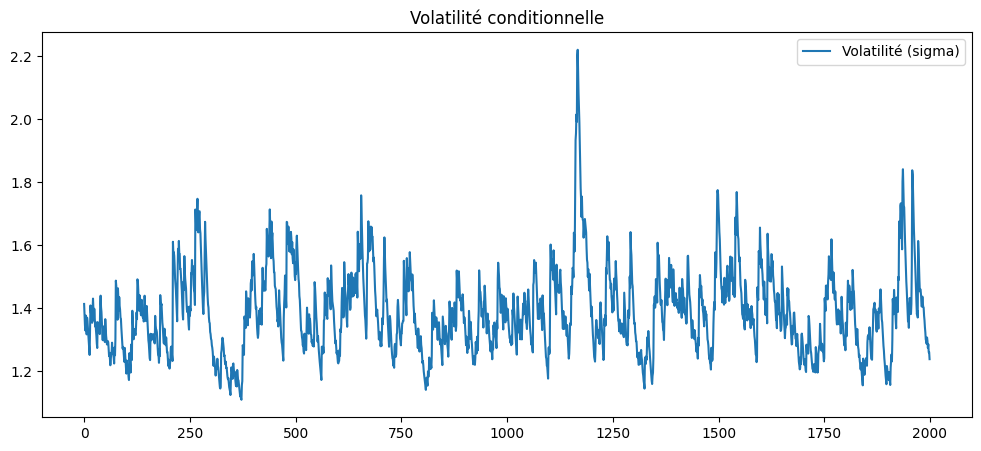

In [189]:
def simulate_garch(T=2000, omega=0.1, alpha=0.05, beta=0.9, mu=0.0, seed=42):
    np.random.seed(seed)
    
    # Initialisation
    eps = np.random.randn(T)
    sigma2 = np.zeros(T)
    r = np.zeros(T)
    
    # Variance initiale (variance inconditionnelle)
    sigma2[0] = omega / (1 - alpha - beta)
    
    for t in range(1, T):
        sigma2[t] = omega + alpha * r[t-1]**2 + beta * sigma2[t-1]
        r[t] = mu + np.sqrt(sigma2[t]) * eps[t]
    
    return r, sigma2

# Simulation
T = 2000
r, sigma2 = simulate_garch(T)

# Plot
plt.figure(figsize=(12,5))
plt.plot(r, label="Rendements")
plt.title("Simulation GARCH(1,1)")
plt.legend()
plt.show()

plt.figure(figsize=(12,5))
plt.plot(np.sqrt(sigma2), label="Volatilité (sigma)")
plt.title("Volatilité conditionnelle")
plt.legend()
plt.show()

#### adapting data for darts

In [216]:
epsilon = 1e-8
log_sigma2 = np.log(sigma2 + epsilon)

# creating Timeseries for Darts
time_index = pd.date_range(start="2000-01-01", periods=len(log_sigma2), freq="D")

series = TimeSeries.from_times_and_values(
    time_index,
    log_sigma2
)

series

,0
2000-01-01,0.693147
2000-01-02,0.641854
2000-01-03,0.594330
2000-01-04,0.570209
2000-01-05,0.640222
...,...
2005-06-18,0.484938
2005-06-19,0.503598
2005-06-20,0.463266
2005-06-21,0.465072


#### split and scaling

In [217]:
train, test = series.split_after(0.8)

scaler = Scaler()

train_scaled = scaler.fit_transform(train)
test_scaled  = scaler.transform(test)
series_scaled = scaler.transform(series)

train_scaled

,0
2000-01-01,0.349190
2000-01-02,0.312206
2000-01-03,0.277939
2000-01-04,0.260547
2000-01-05,0.311029
...,...
2004-05-14,0.510480
2004-05-15,0.503929
2004-05-16,0.474127
2004-05-17,0.577223


In [218]:
test_scaled.time_index[0]

Timestamp('2004-05-19 00:00:00')

#### NBEATS

In [ ]:
from darts.models import NBEATSModel

model = NBEATSModel(
    # 🔹 Structure temporelle
    input_chunk_length=30,
    output_chunk_length=1,
    
    # 🔹 Architecture N-BEATS
    num_stacks=10, # 5 a 10
    num_blocks=1,
    num_layers=4,
    layer_widths=256,
    expansion_coefficient_dim=5,
    
    # 🔹 Type de modèle
    generic_architecture=True,   # très important ici
    trend_polynomial_degree=2,   # utilisé si generic=False
    
    # 🔹 Entraînement
    n_epochs=200,
    batch_size=32,
    
    optimizer_kwargs={
        "lr": 1e-3 #learning rate
    },
    
    # 🔹 Régularisation
    dropout=0.1,
    
    # 🔹 Perte
    #loss_fn=None,  # défaut = MSE
    
    # 🔹 GPU / reproducibilité
    random_state=42,
    pl_trainer_kwargs={
        "accelerator": "auto",
        "devices": "auto",
    },
    
    # 🔹 Early stopping (très recommandé)
    force_reset=True,
    save_checkpoints=True,
)

In [219]:
from darts.models import NBEATSModel
nbeats_name = "model"
model = NBEATSModel(
    input_chunk_length=30,
    output_chunk_length=1,
    
    num_stacks=8,
    num_blocks=1,
    num_layers=4,
    layer_widths=256,
    
    generic_architecture=True,
    
    n_epochs=100,
    batch_size=32,
    optimizer_kwargs={"lr": 1e-3},
    
    dropout=0.1,
    
    random_state=42,

    model_name=nbeats_name,
    save_checkpoints=True,
    force_reset=True
)

model.fit(train_scaled)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | stacks          | ModuleList       | 1.7 M  | train
-------------------------------------------------------------
1.7 M     Trainable params
1.5 K     Non-trainable params
1.7 M     Total params
6.658     Total estimated model params size (MB)
134       Modules in train mode
0         Modules in eval mode
/home/cytech/GITHUB-PROJECT/financial-time-series-forecasting/venv/lib/python3.11/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is depr

Training: |          | 0/? [00:00<?, ?it/s]

/home/cytech/GITHUB-PROJECT/financial-time-series-forecasting/venv/lib/python3.11/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:388: `ModelCheckpoint(monitor='val_loss')` could not find the monitored key in the returned metrics: ['train_loss', 'epoch', 'step']. HINT: Did you call `log('val_loss', value)` in the `LightningModule`?
`Trainer.fit` stopped: `max_epochs=100` reached.


NBEATSModel(output_chunk_shift=0, generic_architecture=True, num_stacks=8, num_blocks=1, num_layers=4, layer_widths=256, expansion_coefficient_dim=5, trend_polynomial_degree=2, dropout=0.1, activation=ReLU, input_chunk_length=30, output_chunk_length=1, n_epochs=100, batch_size=32, optimizer_kwargs={'lr': 0.001}, random_state=42, model_name=model, save_checkpoints=True, force_reset=True)

#### rescale

In [220]:
#model = NBEATSModel.load_from_checkpoint(model_name=nbeats_name, best=True)

pred_scaled = model.historical_forecasts(
    series=series_scaled,
    start=test_scaled.time_index[0],
    forecast_horizon=1,
    stride=1, # the number of time steps between two consecutive predictions.
    retrain=False,
    last_points_only=True
)

# inverse scaling
pred = scaler.inverse_transform(pred_scaled)

# retour variance
sigma2_pred = np.exp(pred.values())
sigma2_true = np.exp(test.values())

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


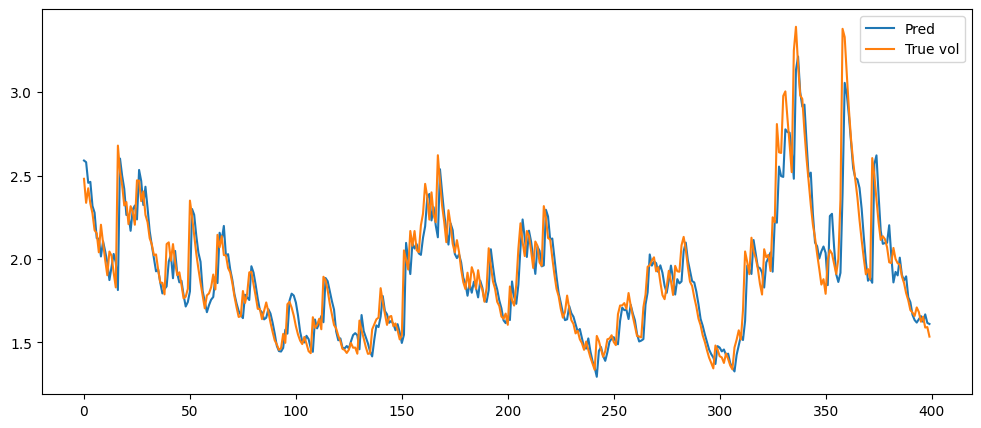

In [222]:
# Plot
plt.figure(figsize=(12,5))
plt.plot(sigma2_pred, label="Pred")
plt.plot(sigma2_true, label="True vol")
plt.legend()
plt.show()

#### GARCH

In [225]:
import numpy as np
from arch import arch_model

split = int(0.8 * len(r))
r_train = r[:split]
r_test  = r[split:]

#r_train_scaled = r_train * 100

model = arch_model(
    r_train,
    vol='GARCH',
    p=1,
    q=1,
    mean='Constant',   
    dist='normal'
)


res = model.fit(disp="off")



print(res.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                      y   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -2778.26
Distribution:                  Normal   AIC:                           5564.51
Method:            Maximum Likelihood   BIC:                           5586.03
                                        No. Observations:                 1600
Date:                Sun, Mar 29 2026   Df Residuals:                     1599
Time:                        23:03:25   Df Model:                            1
                                 Mean Model                                
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
mu             0.0588  3.388e-02      1.735  8.271e-02 [-7.61

#### forcecast dynamic

In [226]:

history = list(r_train)

sigma2_preds = []

for t in range(len(r_test)):
    
    # Refit avec toutes les vraies données jusqu'à t
    model = arch_model(history, vol='GARCH', p=1, q=1, mean='Constant')
    res = model.fit(disp="off")
    
    forecast = res.forecast(horizon=1)
    
    sigma2_t = forecast.variance.values[-1, 0]
    sigma2_preds.append(sigma2_t)
    
    # Ajouter la vraie observation
    history.append(r_test[t])


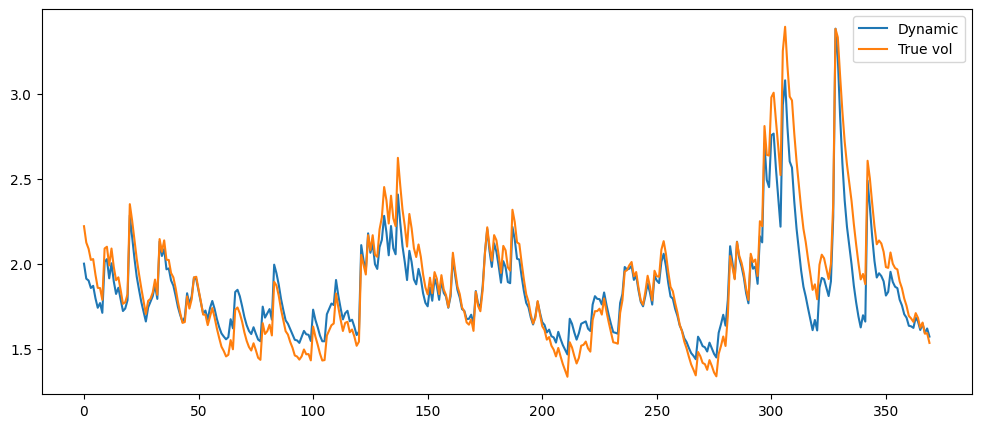

In [227]:
# Plot
plt.figure(figsize=(12,5))
plt.plot(sigma2_preds[30:], label="Dynamic")
plt.plot(sigma2_true[30:], label="True vol")
plt.legend()
plt.show()

### Erreur

In [234]:
mse_garch = np.mean((sigma2_preds - sigma2_true)**2)
print("MSE GARCH:", mse_garch)

# weird bc comparing with the day before gives better results
mse_nbeats = np.mean((sigma2_pred[1:] - sigma2_true[:-1])**2)
print("MSE NBEATS:", mse_nbeats)

MSE GARCH: 0.21693635154260113
MSE NBEATS: 0.003999580392839397


In [233]:
mse_garch = np.mean((sigma2_preds - sigma2_true)**2)
print("MSE GARCH:", mse_garch)

mse_nbeats = np.mean((sigma2_pred - sigma2_true)**2)
print("MSE NBEATS:", mse_nbeats)

MSE GARCH: 0.21693635154260113
MSE NBEATS: 0.021710789231663242


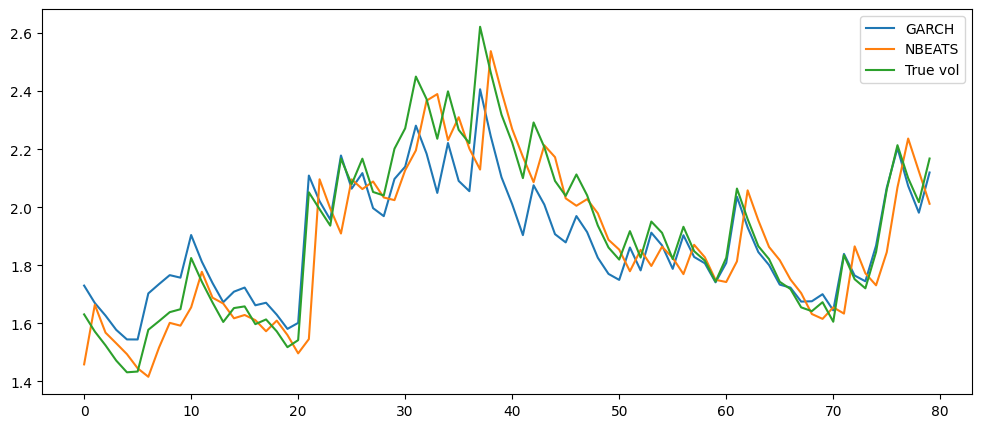

In [236]:
# Plot
plt.figure(figsize=(12,5))
plt.plot(sigma2_preds[130:210], label="GARCH")
plt.plot(sigma2_pred[130:210], label="NBEATS") #we can see the one day late
plt.plot(sigma2_true[130:210], label="True vol")
plt.legend()
plt.show()

In [238]:
#checking prediction dates matches and there is no gap 
print(pred.time_index[:5])
print(test.time_index[:5])

DatetimeIndex(['2004-05-19', '2004-05-20', '2004-05-21', '2004-05-22',
               '2004-05-23'],
              dtype='datetime64[ns]', freq='D')
DatetimeIndex(['2004-05-19', '2004-05-20', '2004-05-21', '2004-05-22',
               '2004-05-23'],
              dtype='datetime64[ns]', freq='D')


In [239]:
# creating stupid prevision like simga(t-1) = sigma(t)
stupid = [0]
for t in range(0,len(sigma2_true)):
    stupid.append(sigma2_true[t][0])

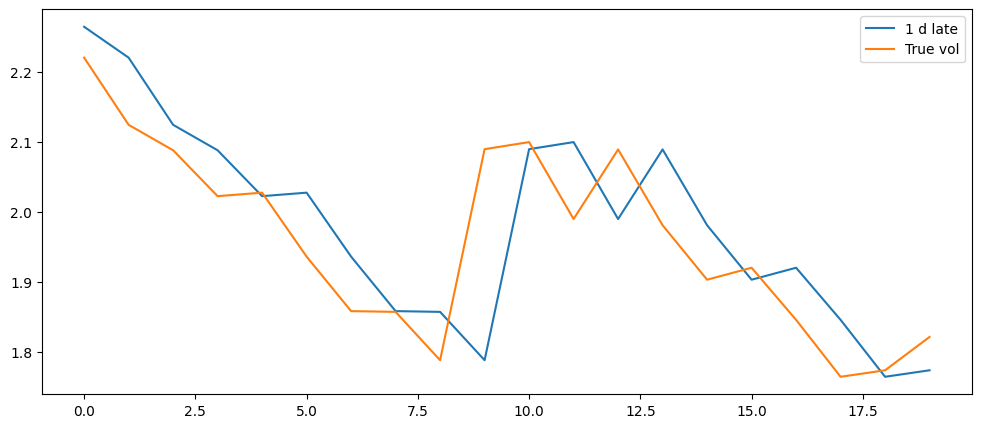

In [240]:
# Plot
plt.figure(figsize=(12,5))
#plt.plot(sigma2_preds, label="GARCH")
plt.plot(stupid[30:50], label="1 d late")
plt.plot(sigma2_true[30:50], label="True vol")
plt.legend()
plt.show()

In [241]:
mse_stupid= np.mean((stupid[1:] -sigma2_true[1:])**2)
print("MSE NBEATS:", mse_stupid) #not as good as NBEATS but comparable to garch

MSE NBEATS: 0.2734558327225095


In [242]:
# aligning on date index, still getting this weird lookalike on day gap
common_times = pred.time_index.intersection(test.time_index)

pred_aligned = pred.slice_intersect(test)
true_aligned = test.slice_intersect(pred)

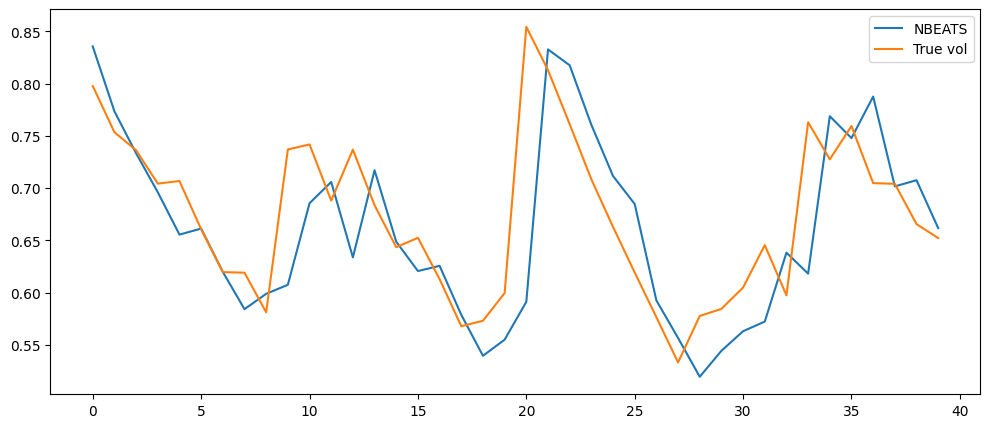

In [243]:
# Plot
plt.figure(figsize=(12,5))
#plt.plot(sigma2_preds, label="GARCH")
plt.plot(pred_aligned.values()[30:70,0], label="NBEATS")
plt.plot(true_aligned.values()[30:70,0], label="True vol")
plt.legend()
plt.show()